https://arxiv.org/pdf/2601.20218

## 《DenseGRPO: Aligning Flow Matching Models with Dense Rewards》

这篇论文《DenseGRPO: 从稀疏到密集的奖励用于流匹配模型对齐》提出了一种新框架，核心目标是解决在利用强化学习（特别是GRPO算法）对齐文本到图像生成模型时，存在的**奖励信号稀疏**问题。

下面我将从问题背景、核心方法、主要贡献和实验结论几个方面为你详细解读。

---

### 1. 研究背景与核心问题

当前，像Stable Diffusion 3这样的先进文本到图像模型大多基于**流匹配（Flow Matching）** 模型。为了让生成的图像更符合人类偏好（如更好的图文一致性、美观度等），研究者引入**强化学习**进行微调，其中**GRPO（Group Relative Policy Optimization）** 是最主流的方法。

然而，现有的GRPO方法存在一个关键缺陷：**稀疏奖励问题**。

*   **传统做法**：模型生成一张图需要经过一个多步（比如10步）的去噪过程。现有方法只在最后一步生成完整图像后，才用奖励模型给一个总分（比如“这张图的美学分数是8分”）。然后，**这个最终总分被不加区分地当作每一步去噪操作的奖励信号**。
*   **问题所在**：这好比一个团队完成了一个项目，老板只根据最终成果给了团队一笔总奖金，然后让团队成员平分。这完全忽略了每个成员在项目中不同阶段的贡献大小。在生成模型中，这意味着每一步去噪（从纯噪声到显现轮廓，再到添加细节）对最终结果的贡献是不同的，用同一个全局反馈去指导所有步骤，会导致训练信号不准确，优化效率低下。

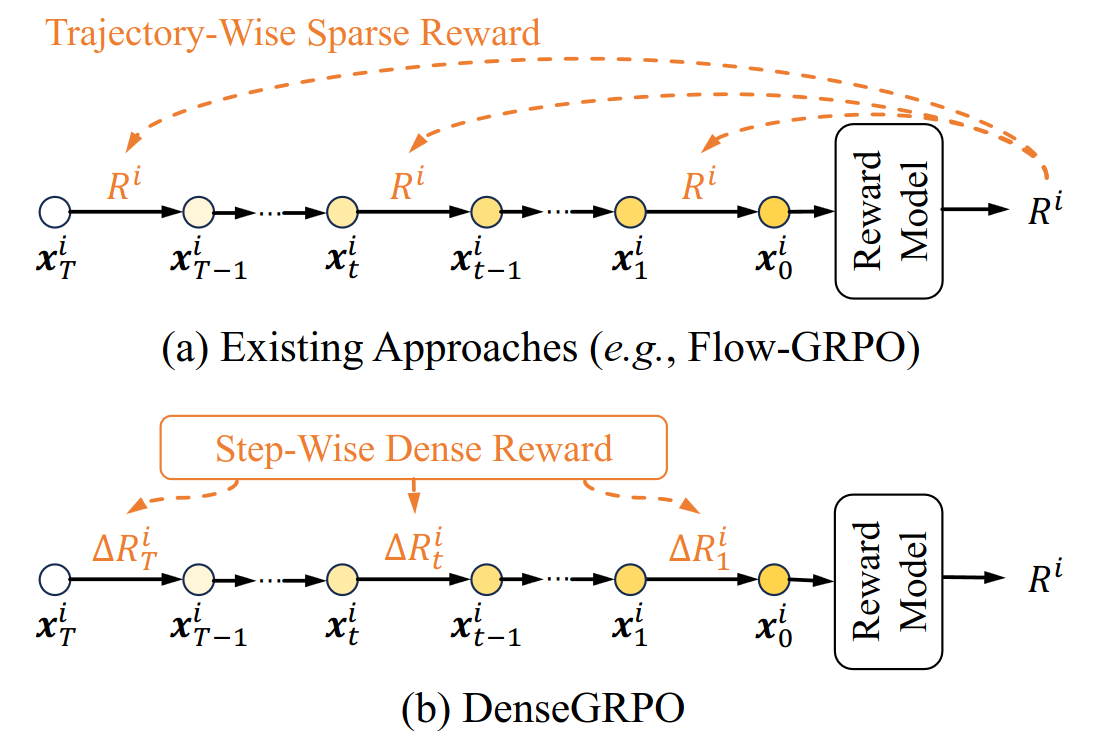

---

### 2. DenseGRPO的核心方法

为了解决上述问题，DenseGRPO提出了两个关键创新点：

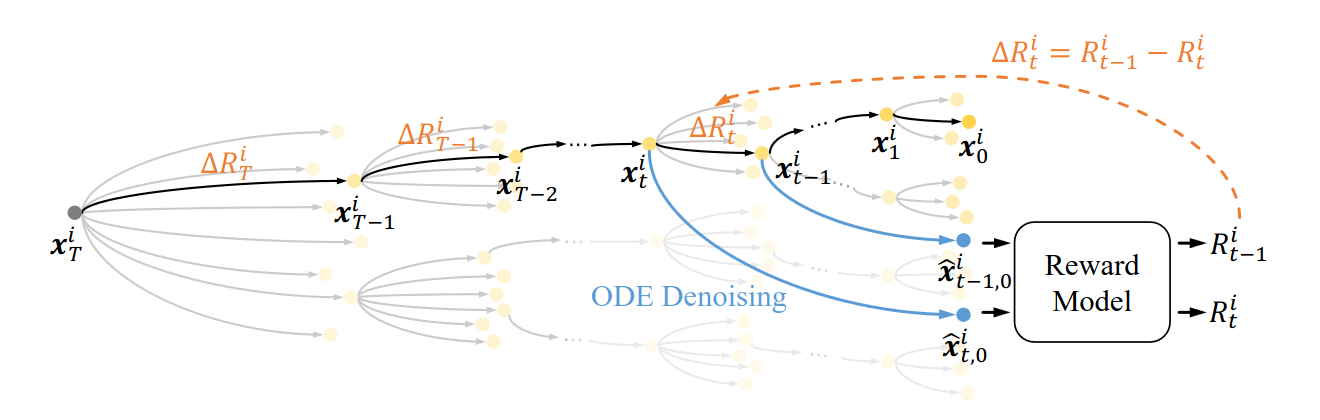

#### 创新点一：逐步骤的密集奖励评估

这是论文的核心思想。DenseGRPO不再只看最终结果，而是试图**量化每一个去噪步骤的“收益”**，实现精细化的信用分配。

*   **方法**：
    1.  **获取中间状态的奖励**：对于去噪过程中的任何一个中间潜变量 $ x_t^i $，DenseGRPO会利用流匹配模型的确定性特性（通过一个ODE求解器），从 $ x_t^i $ 快速“预测”出它最终会生成什么样的干净图像。
    2.  **计算单步收益**：将去噪过程看作一个马尔可夫决策过程，状态 $ t $ 的潜变量 $ x_t^i $ 能获得的未来奖励是 $ R_t^i $，去一步噪到达状态 $ t-1 $ 的奖励是 $ R_{t-1}^i $。那么，**这一步去噪操作的“贡献” $ \Delta R_t^i $ 就被定义为奖励的增益：$ R_{t-1}^i - R_t^i $**。
    3.  **分配奖励**：在GRPO的优化目标中，用这个细粒度的 $ \Delta R_t^i $ 替换掉原来全局的、稀疏的奖励，来指导每一步的优化。这样，好的去噪步会得到正的奖励增益，不好的步则会得到负的惩罚。

*   **优势**：
    *   **信号精确**：反馈信号与每一步的实际贡献精确对齐。
    *   **无需额外模型**：这种方法巧妙地复用了现有的奖励模型和ODE求解器，不需要训练一个额外的“过程奖励模型”，降低了训练成本和复杂性。

#### 创新点二：基于奖励感知的探索空间校准

GRPO算法需要模型在训练时进行随机探索，以生成多样化的样本来计算优势。现有方法通过在SDE（随机微分方程）采样器中**统一注入噪声**来实现。

*   **新发现的问题**：论文发现，这种统一的噪声注入是不合理的。因为去噪过程是时变的——早期步骤噪声大，探索空间应该大；后期步骤接近清晰图像，微小的扰动就可能毁掉图像。统一的强噪声会导致后期探索“失控”，几乎所有探索样本的奖励都是负的（图3a），这导致奖励分布失衡，优化失败。
*   **提出的解决方法**：DenseGRPO提出了一种**自适应的、时间步特异的噪声注入策略 $ \psi(t) $**。
    *   **核心思想**：一个好的探索空间应该既能保持样本的多样性，又能保证正负奖励样本的数量大致平衡。如果某个时间步的奖励全是负的，说明探索过度，应降低噪声；反之则可以适当增加噪声以增加多样性。
    *   **实现方式**：通过迭代采样的方式，为每个时间步 $ t $ 独立地校准一个合适的噪声水平 $ \psi(t) $，确保在所有去噪步骤中都有一个健康、平衡的探索空间，从而让GRPO的训练更加稳定和有效。

---

### 3. 主要贡献

1.  **提出了DenseGRPO框架**：首次在流匹配模型的对齐任务中引入**逐步骤密集奖励**，实现了对去噪过程每一步贡献的精细评估，解决了长期存在的奖励信号不匹配问题。
2.  **揭示了探索不平衡问题**：发现并分析了现有方法中统一噪声注入与去噪过程时变性之间的不匹配，指出这会导致不恰当的探索空间。
3.  **设计了自适应探索校准方案**：提出了一种基于奖励反馈的、时间步特异的噪声调整机制，有效地平衡了探索的多样性和稳定性。
4.  **实验效果显著**：在多个标准测试基准上，DenseGRPO都取得了优于此前最先进方法（如Flow-GRPO）的性能，验证了密集奖励和校准探索空间的有效性。

---

### 4. 实验与结论

论文在三个典型的文本到图像任务上进行了实验：
*   **组合式图像生成**：测试模型根据复杂描述生成正确属性、关系的图像能力。
*   **视觉文本渲染**：测试模型生成清晰准确文字的能力。
*   **人类偏好对齐**：测试模型生成图像的整体美观度和与人类偏好的符合度。

实验结果表明，DenseGRPO在所有任务上的性能均大幅超越基于稀疏奖励的Flow-GRPO，以及同样尝试进行步骤级信用分配的CoCA方法。特别是在人类偏好对齐任务上，PickScore提升了1.01分，提升显著。消融研究也分别验证了**密集奖励**和**探索空间校准**两个模块的独立贡献，并指出更精确的奖励估计（使用更多ODE步骤）能带来更好的性能。

**结论**：DenseGRPO通过提供精确的步骤级反馈和平衡的探索空间，显著提升了流匹配模型的对齐效果，证明了在文本到图像生成领域，对生成过程进行精细化反馈是未来发展的关键方向。


## 3. 预备知识

### 3.1 流匹配模型的强化学习形式化

Flow matching 的迭代去噪过程被建模为**马尔可夫决策过程（MDP）**：

- **状态**：$ s_t = (c, t, \mathbf{x}_t) $，包含提示词 $ c $、当前时间步 $ t $ 和当前潜变量 $ \mathbf{x}_t $。
- **动作**：预测的下一潜变量 $ \mathbf{a}_t = \mathbf{x}_{t-1} $。
- **策略**：$ \pi(\mathbf{a}_t|s_t) = p_\theta(\mathbf{x}_{t-1}|\mathbf{x}_t, c) $。
- **状态转移**：确定性转移 $ \mathcal{P}(s_{t+1}|s_t, \mathbf{a}_t) = (\delta_c, \delta_{t-1}, \delta_{\mathbf{x}_{t-1}}) $。
- **奖励**：仅在终端状态给奖励 $ R(\mathbf{x}_0, c) $，中间步骤奖励为 0。

这正是**稀疏奖励**的根源。

### 3.2 GRPO 框架

对于一条提示 $ c $，采样 $ G $ 条轨迹，得到终端奖励 $ R(\mathbf{x}_0^i, c) $。**优势函数**通过组内标准化计算：

$$
\hat{A}^i_t = \frac{R(\mathbf{x}_0^i, c) - \operatorname{mean}(\{R(\mathbf{x}_0^j, c)\}_{j=1}^G)}{\operatorname{std}(\{R(\mathbf{x}_0^j, c)\}_{j=1}^G)}.
\tag{2}
$$

注意：这个优势函数与时间步 $ t $ **无关**，所有步骤共享同一个优势值。  
优化目标为：

$$
\mathcal{J}_{\text{Flow-GRPO}}(\theta) = \mathbb{E}_{c,\{\mathbf{x}^i\}\sim\pi_{\theta_{\text{old}}}} \frac{1}{G}\sum_{i=1}^G \frac{1}{T}\sum_{t=0}^{T-1} \left( \min(r_t^i(\theta) \hat{A}^i_t, \operatorname{clip}(r_t^i(\theta),1-\epsilon,1+\epsilon)\hat{A}^i_t) - \beta D_{\text{KL}}(\pi_\theta\|\pi_{\text{ref}}) \right),
\tag{3}
$$

其中 $ r_t^i(\theta) = \frac{p_\theta(\mathbf{x}_{t-1}^i|\mathbf{x}_t^i, c)}{p_{\theta_{\text{old}}}(\mathbf{x}_{t-1}^i|\mathbf{x}_t^i, c)} $。

### 3.3 SDE 采样器

为了探索多样性，Flow-GRPO 将确定性 ODE 采样器：

$$
d\mathbf{x}_t = \mathbf{v}_t dt
$$

转化为一个等价但增加噪声的 SDE 采样器：

$$
\mathbf{x}_{t+\Delta t} = \mathbf{x}_t + \left[ \mathbf{v}_\theta(\mathbf{x}_t, t) + \frac{\sigma_t^2}{2t}(\mathbf{x}_t + (1-t)\mathbf{v}_\theta(\mathbf{x}_t, t)) \right]\Delta t + \sigma_t\sqrt{\Delta t}\,\boldsymbol{\epsilon},
\tag{6}
$$

其中 $ \sigma_t = a\sqrt{\frac{t}{1-t}} $，$ \boldsymbol{\epsilon}\sim\mathcal{N}(\mathbf{0},\mathbf{I}) $。超参数 $ a $ 控制额外噪声水平。当 $ a $ 选择恰当时可等价于 ODE，但此处 $ a $ 被人工设定为固定值以注入更多噪声，导致采样轨迹偏离原始概率路径。

---


##  **第 4 节 DenseGRPO**

---

### 4.1 步骤级密集奖励

这部分的核心目标是：**为去噪轨迹上的每一个时间步 $t$，分配一个能精确反映该步贡献的奖励信号 $\Delta R_t^i$。**

#### 4.1.1 动机：稀疏奖励的错配

现有方法（如 Flow-GRPO）的做法是：
1.  采样一条完整的去噪轨迹：$ \mathbf{x}_T \rightarrow \mathbf{x}_{T-1} \rightarrow \dots \rightarrow \mathbf{x}_0 $。
2.  仅对最终图像 $ \mathbf{x}_0 $ 用奖励模型打分，得到轨迹级奖励 $ R^i $。
3.  用这**同一个** $ R^i $ 来计算优势函数 $ \hat{A}^i $，并用于优化轨迹上**所有**的中间去噪步。

**问题所在：**
-   最终奖励 $ R^i $ 是所有 $ T $ 步去噪操作的**累积贡献**。
-   将它直接作为单步（比如从 $ \mathbf{x}_t $ 到 $ \mathbf{x}_{t-1} $）的反馈信号，等于默认了每一步的贡献是一样的。
-   这显然是错误的。早期步骤可能负责构建整体布局，后期步骤负责雕琢细节。错误的反馈信号会误导策略，使其无法精准地强化好的行为、抑制坏的行为。

**DenseGRPO 的解决思路：**
我们需要一个步骤级的反馈，它应该回答的问题是：“**从状态 $\mathbf{x}_t$ 到 $\mathbf{x}_{t-1}$ 的这一次去噪操作，到底带来了多少增益？**”

---

#### 4.1.2 定义：奖励增益作为密集奖励

为了量化单步贡献，DenseGRPO 引入了**奖励增益**的概念。

首先，假设我们能评估轨迹上任意中间状态 $ \mathbf{x}_t $ 的“未来潜力”，记作 $ R_t $。这个 $ R_t $ 代表“如果从当前状态 $ \mathbf{x}_t $ 出发，最终能生成多好的图像”。

有了这个定义后，从 $ \mathbf{x}_t $ 去噪到 $ \mathbf{x}_{t-1} $ 这一步的**贡献**就变得清晰了：它使得状态的未来潜力从 $ R_t $ 变为了 $ R_{t-1} $。因此，这一步骤的密集奖励被定义为**奖励增益**：

$$
\Delta R^i_t = R^i_{t-1} - R^i_t
\tag{7}
$$

-   如果这一步去噪让未来潜力提升了（$ R_{t-1} > R_t $），那么 $ \Delta R_t > 0 $，是正向贡献。
-   如果这一步去噪反而破坏了图像，导致未来潜力下降（$ R_{t-1} < R_t $），那么 $ \Delta R_t < 0 $，是负向贡献。

这个定义巧妙地将稀疏的终端奖励转化为一个沿时间步展开的密集奖励序列。

---

#### 4.1.3 实现：用 ODE 确定性推演未来

定义虽然完美，但如何获得任意中间状态 $ \mathbf{x}_t $ 的 $ R_t $ 呢？毕竟我们无法直接给一团充满噪声的潜变量打分。DenseGRPO 利用流匹配模型的一个核心性质来解决：**确定性 ODE 的一一映射**。

-   **核心性质**：对于流匹配模型，给定一个状态 $ \mathbf{x}_t $，如果用一个**确定性 ODE 求解器**（无随机噪声）从 $t$ 积分到 $0$，得到的干净潜变量 $ \hat{\mathbf{x}}_{t,0} $ 是唯一确定的。
-   **具体操作（公式 8）**：
    1.  从 SDE 采样轨迹中取出一个中间状态 $ \mathbf{x}_t^i $。
    2.  将其作为起点，执行 $n$ 步确定性 ODE 去噪，得到一个预测的干净潜变量：
        $$
        \hat{\mathbf{x}}_{t,0}^i = \text{ODE}_n(\mathbf{x}_t^i, c)
        \tag{8}
        $$
        这里 ODE 求解器内部是确定性的，每一步更新是 $ \mathbf{x}_{\tau-\Delta\tau} = \mathbf{x}_\tau + \mathbf{v}_\theta(\mathbf{x}_\tau, \tau, c)\Delta\tau $，没有噪声注入。
    3.  将 $ \hat{\mathbf{x}}_{t,0}^i $ 解码为干净图像，然后送入任意一个现成的奖励模型 $ \mathcal{R} $ 进行打分。**这个分数，就被定义为状态 $\mathbf{x}_t$ 的未来奖励 $R^i_t$**：
        $$
        R^i_t \triangleq \mathcal{R}(\hat{\mathbf{x}}_{t,0}^i, c)
        \tag{9}
        $$

**为什么这个方法是有效的？**
-   **可靠性**：奖励模型是在干净图像上训练的。通过 ODE 推演，我们为每个中间状态生成了一个对应的、清晰的“宿命图像”，从而能用奖励模型可靠地评估其未来潜力。
-   **无需额外模型**：整个过程复用了已有的**速度场网络**（做 ODE 推演）和**奖励模型**（打分），不需要像传统 RL 那样训练一个专门的价值函数网络来估计 $ R_t $。

---

#### 4.1.4 融入 GRPO 框架

有了步骤级的密集奖励 $ \Delta R^i_t $，就可以直接替换 GRPO 中原有的稀疏奖励。

原始的 GRPO 中，整个轨迹所有步共享同一个优势函数（公式 2）。现在，DenseGRPO 为每个时间步 $t$ 独立计算优势函数：

$$
\hat{A}^i_t = \frac{\Delta R^i_t - \operatorname{mean}(\{\Delta R^j_t\}_{j=1}^G)}{\operatorname{std}(\{\Delta R^j_t\}_{j=1}^G)}
\tag{10}
$$

-   **组内比较**：优势函数依然在组内（`G` 个样本）进行标准化，但它比较的不再是最终结果，而是**在同一个时间步 $t$ 上，不同样本的表现差异**。
-   **优化目标**：GRPO 的优化目标（公式 3）在形式不变，但其内部的 `A_hat` 从轨迹级常量变成了时间步相关的 `A_hat_t`。这使得优化过程能精确地强化那些带来正向奖励增益的去噪步，抑制那些带来负增益的去噪步，解决了反馈错配问题。

---

### 4.2 探索空间校准

这部分解决的是 **如何为 SDE 采样器设置合理的探索噪声** 的问题。

#### 4.2.1 问题发现：统一噪声与时间异质性的错配

-   **现有方法**：Flow-GRPO 的 SDE 采样器用一个统一超参数 $a$ 控制所有时间步的噪声水平（公式 6）。
-   **发现的问题**：去噪过程是**时间异质的**。早期（高噪声阶段）和晚期（低噪声阶段）对额外注入噪声的容忍度截然不同。统一的 $a$ 无法适配这种变化。
-   **密集奖励的诊断能力**：DenseGRPO 的密集奖励恰好能用来诊断这个问题。通过可视化每个时间步的 $ \Delta R_t $（如图 3），论文发现：
    -   当 $a=0.7$ 时，在某些后期时间步（如 $t=2$），几乎所有样本的 $ \Delta R_t $ 都是负数（图 3a）。这表明噪声过大，导致探索空间崩溃，所有探索行为都只得到负反馈。
    -   减小 $a$（如 0.5）可以缓解后期的负奖励问题，但会牺牲早期步的探索多样性（图 3b）。

**结论**：需要一个**时间步特定的噪声强度** $ \psi(t) $，为每一步找到探索与稳定性的最佳平衡点。

---

#### 4.2.2 自适应校准算法（Algorithm 1）
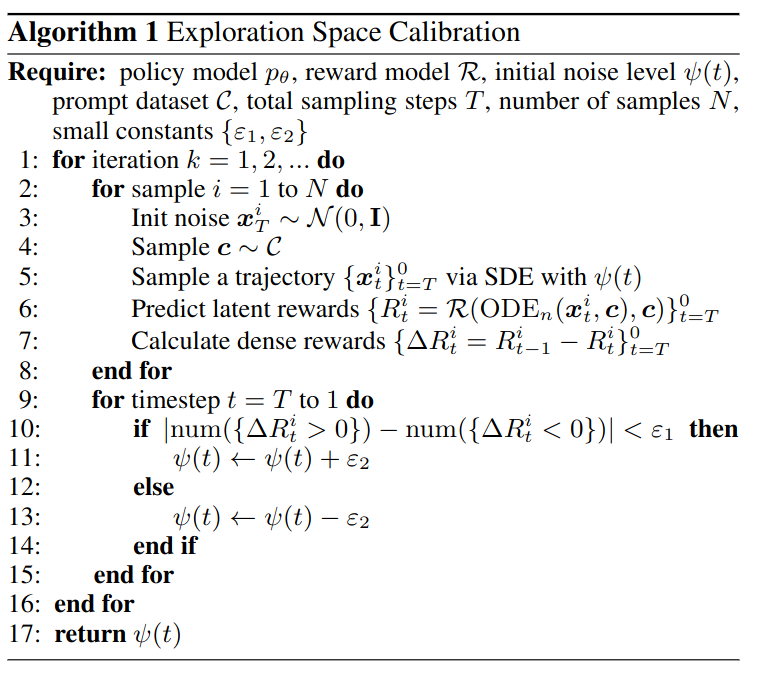

目标是找到一个噪声水平表 $ \psi(t) $，使得在每个时间步 $t$ 上，探索得到的密集奖励 $ \Delta R_t $ 正负样本大致平衡。

**校准过程**：

1.  **初始化**：为所有时间步 $t$ 设置一个初始噪声水平 $ \psi(t) $。
2.  **采样与评估**：
    -   用当前 $ \psi(t) $ 的 SDE 采样器生成 $N$ 条完整的去噪轨迹。
    -   对每条轨迹，按照 4.1 节方法计算出所有时间步的密集奖励 $ \Delta R^i_t $。
3.  **按时间步诊断平衡性**：
    -   针对每个时间步 $t$，统计这 $N$ 个样本中，$ \Delta R_t > 0 $ 的数量 $ N^+_t $ 和 $ \Delta R_t < 0 $ 的数量 $ N^-_t $。
    -   计算不平衡度：$|N^+_t - N^-_t|$。
4.  **启发式调整**：
    -   **如果平衡**（$|N^+_t - N^-_t| < \varepsilon_1$）：说明当前探索空间健康，有正有负。可以**略微增大噪声** `ψ[t] += ε2` 来尝试获得更多样化的探索。
    -   **如果失衡**（$|N^+_t - N^-_t| \ge \varepsilon_1$）：说明噪声大小不合适。通常是噪声过大导致全是负奖励。此时需要**减小噪声** `ψ[t] -= ε2` 来约束探索空间。
5.  **迭代至收敛**：重复步骤 2-4，直到所有时间步的 $ \psi(t) $ 值趋于稳定。

**最终效果**：
得到一条自适应的噪声曲线 $ \psi(t) $。用它替换原 SDE 采样器中的 `a * sqrt(t/(1-t))`，使噪声项简化为 `σ_t = ψ(t)`。这个校准过程是离线的，在正式 GRPO 训练前完成，开销极小。

---

### 总结：DenseGRPO 方法的完整逻辑链

1.  **发现问题**：传统 GRPO 用稀疏的终端奖励优化多步去噪过程，导致反馈与贡献错配。
2.  **提出方案（密集奖励）**：定义步骤级奖励为“奖励增益” $\Delta R_t = R_{t-1} - R_t$。通过确定性 ODE 从中间状态推演未来，用奖励模型为每个状态打分，从而计算出这个增益。
3.  **解决衍生问题（探索校准）**：密集奖励揭示了 SDE 统一噪声导致的探索失衡。通过分析每个时间步的 $\Delta R_t$ 正负分布，自适应地调整出一个时间步特定的噪声表 $ \psi(t) $，确保所有步骤都有一个健康的探索空间。
4.  **形成闭环**：一个精准的步骤级反馈信号，配合一个健康的探索空间，共同保证了 GRPO 策略优化能高效、稳定地进行，从而实现对人类偏好的精准对齐。